# Modeling cardiac muscle fibers in left ventricular electrophysiology simulations


-------
This script implements the Laplace-Dirichlet-Rule-Based-Method (LDRBM) to
generate cardiac fibers in Firedrake. The workflow follows these steps:

1. Fiber implementation on a simple cubic domain.
2. Extension to an idealized ventricular geometry.
3. Fiber generation and activation map simulation on a realistic left
   ventricle geometry, comparing isotropic and anisotropic electrical propagation.


--------

Reference:

Piersanti R.,ù et al. (2021). "Modeling cardiac muscle fibers in ventricular and atrial electrophysiology simulations".

Computer Methods in Applied Mechanics and Engineering, 373, 113468.

DOI: https://doi.org/10.1016/j.cma.2020.113468

## Cube

In [13]:
%%capture
# 1. Install library
!apt-get update && apt-get install -y libspatialindex-dev libglu1-mesa gmsh

# 2. Dawnload and execute the installation script of Firedrake
!wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "firedrake-install.sh"
!bash "firedrake-install.sh"

# 3. Extra utilities
%pip install pygmsh pyvista meshio

In [14]:
import firedrake

In [ ]:
from firedrake import *

# Labelled mesh (i.e. Define the Domain)
# We create a 10x10x10 unit cube to simulate a tissue block.
# In Firedrake's UnitCubeMesh, the boundary IDs are:
# 1: x=0 (Endocardium), 2: x=1 (Epicardium), 5: z=0, 6: z=1 (Base)
mesh = UnitCubeMesh(10, 10, 10)

# Define the function spaces
# V is for scalar functions (the transmural distance)
# V_vec is for vector fields (the fibers and axes)
V = FunctionSpace(mesh, "CG", 1)
V_vec = VectorFunctionSpace(mesh, "CG", 1)

# Transmural Distance (Solving the Laplace Problem)
u = TrialFunction(V)
v = TestFunction(V)

# Weak form of the Laplace equation: -\Delta \phi = 0
a = inner(grad(u), grad(v)) * dx
L = Constant(0.0) * v * dx

# Dirichlet boundary conditions:
# phi = 0 on the endocardium (id=1), phi = 1 on the epicardium (id=2)
bcs = [DirichletBC(V, 0.0, 1), DirichletBC(V, 1.0, 2)]

# Solve the linear system
phi = Function(V, name="Transmural_Distance")
solve(a == L, phi, bcs=bcs)

# Transmural Direction
# Calculate the normalized gradient of phi
eps = 1e-12
grad_phi = grad(phi)
e_t = grad_phi / sqrt(inner(grad_phi, grad_phi) + eps)

# Normal Direction
# In R-RBM, the reference normal direction (k) is simply the
# outward normal to the ventricular base. Here, the base is at z=1.
k = Constant((0.0, 0.0, 1.0))

# Local Coordinate System
# Local normal direction (e_n): remove the transmural component from k
e_n_temp = k - inner(k, e_t) * e_t
e_n = e_n_temp / sqrt(inner(e_n_temp, e_n_temp))

# Local longitudinal direction (e_l)
e_l = cross(e_n, e_t)

# The orthonormal triad (e_t, e_n, e_l) is now complete

# Rotate Axis (Generating the Fiber Field)
# Convert typical endo/epi angles to radians
alpha_endo = Constant(-60.0 * pi / 180.0)
alpha_epi = Constant(+60.0 * pi / 180.0)

# Linear interpolation of the rotation angle based on depth (phi):
# if phi=0 (Endo)->+60°, if phi=1 (Epi) -> -60°
alpha = alpha_epi * (1.0 - phi) + alpha_endo * phi

# Rotate the longitudinal vector around the transmural axis
f_math = cos(alpha) * e_l + sin(alpha) * e_n

# Project the mathematical formulation into our vector space
fiber_field = project(f_math, V_vec, name="Fiber_Direction")

# Beta angle for sheetlet direction (this part of the code can be reused in the subsequent plots)
# 2. Define sheet angles (beta) from endo to epi (typical values e.g., +30° to -30°)
beta_endo = Constant(90.0 * pi / 180.0)
beta_epi = Constant(-25.0 * pi / 180.0)
beta = beta_epi * (1.0 - phi) + beta_endo * phi

# 3. Intermediate vectors before sheet rotation
# Tana di riferimento iniziale per i foglietti prima della rotazione beta
s_init = cross(e_t, fiber_field)
n_init = e_t

# 4. Rotate sheet vectors around the fiber axis by angle beta
# (Applicazione della seconda rotazione attorno all'asse della fibra f)
s_math = cos(beta) * s_init + sin(beta) * cross(fiber_field, s_init)
n_math = cross(fiber_field, s_math)

# Project sheet directions into vector spaces
sheet_direction = project(s_math, V_vec, name="Sheet_Direction")

# Normal direction
normal_direction = project(n_math, V_vec, name="Normal_Direction")

# 7. Output Results
# Save the scalar field (distance) and vector field (fibers) for ParaView
output_file = VTKFile("cube_fibers.pvd")
output_file.write(phi, fiber_field, sheet_direction, normal_direction)
print("Simulation complete! The file cube_fibers.pvd is ready.")

Simulation complete! The file cube_fibers.pvd is ready.


Fiber visualization

In [ ]:
import pyvista as pv

# Set the 'html' backend for interactivity within the notebook
pv.set_jupyter_backend('html')

grid = pv.read("cube_fibers/cube_fibers_0.vtu")
grid.set_active_vectors("Fiber_Direction")

# Reduce visual clutter: use 'tolerance' to display fewer arrows (Higher tolerance values result in fewer arrows being drawn).
# Scale=False in order to have all arrows with the exact same length.
arrows = grid.glyph(orient="Fiber_Direction", factor=0.08, scale=False, tolerance=0.05)

plotter = pv.Plotter()

# Make the cube slightly transparent (opacity=0.2) to visualize the interior arrows
plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.2,
                 show_scalar_bar=True, scalar_bar_args={'title': "Distanza (phi)"})

plotter.add_mesh(arrows, color="black")

# Interactive rendering
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

 Sheets visualization

In [ ]:
import pyvista as pv

# Set the 'html' backend for interactivity within the notebook
pv.set_jupyter_backend('html')

grid = pv.read("cube_fibers/cube_fibers_0.vtu")

# Arrows for fibers
grid.set_active_vectors("Fiber_Direction")
arrows_fiber = grid.glyph(orient="Fiber_Direction", factor=0.08, scale=False, tolerance=0.05)

# Arrows for sheets
grid.set_active_vectors("Sheet_Direction")
arrows_sheet = grid.glyph(orient="Sheet_Direction", factor=0.08, scale=False, tolerance=0.05)

# plotter
plotter = pv.Plotter()

# Cube and transmural distance
plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.15,
                 show_scalar_bar=True, scalar_bar_args={'title': "Distance (phi)"})

# fibers
#plotter.add_mesh(arrows_fiber, color="black", name="Fibers")

# Sheetlets
plotter.add_mesh(arrows_sheet, color="red", name="Sheets")

# Render
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Cube fibers animated GIF

In [ ]:
import pyvista as pv

# Data upload
grid = pv.read("cube_fibers/cube_fibers_0.vtu")
grid.set_active_vectors("Fiber_Direction")

# scale=False (again, same length for visualization purposes)
arrows = grid.glyph(orient="Fiber_Direction", factor=0.08, scale=False, tolerance=0.05)

# Plotter setup for video
# off_screen=True is essential on Colab for background video rendering
plotter = pv.Plotter(off_screen=True)

plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.3,
                 show_scalar_bar=True, scalar_bar_args={'title': "Distance (phi)"})

plotter.add_mesh(arrows, color="black")

# Animated gif creation
gif_filename = "cubo_fibre_rotante.gif"
plotter.open_gif(gif_filename)

# Initial camera position
plotter.view_isometric()

# Number of frames
n_frames = 360

print("Generating GIF...")

for i in range(n_frames):
    # Rotate the camera (azimuth) by 1 degree per loop
    plotter.camera.azimuth += 1 #(360 frames of 1 degree each = 360 degrees)

    # Render and save the single frame to the file
    plotter.render()
    plotter.write_frame()

# Render and save the single frame to the file
plotter.close()
print(f"Done! '{gif_filename}' available for download.")

Generating GIF...
Done! 'cubo_fibre_rotante.gif' available for download.


Cube fibers and sheetlets animation

In [ ]:
import pyvista as pv

# Data upload
grid = pv.read("cube_fibers/cube_fibers_0.vtu")

# --- 1. GLIFI PER LE FIBRE (f) ---
grid.set_active_vectors("Fiber_Direction")
arrows_fiber = grid.glyph(orient="Fiber_Direction", factor=0.08, scale=False, tolerance=0.05)

# --- 2. GLIFI PER I FOGLIETTI (s) ---
grid.set_active_vectors("Sheet_Direction")
arrows_sheet = grid.glyph(orient="Sheet_Direction", factor=0.08, scale=False, tolerance=0.05)

# Plotter setup for video
# off_screen=True is essential on Colab for background video rendering
plotter = pv.Plotter(off_screen=True)

# Traccia il cubo con la distanza transmurale di sfondo
plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.15,
                 show_scalar_bar=True, scalar_bar_args={'title': "Distance (phi)"})

# Aggiungi entrambe le direzioni con colori diversi (es. nere per le fibre, blu per i foglietti)
plotter.add_mesh(arrows_fiber, color="black", name="Fibers")
plotter.add_mesh(arrows_sheet, color="blue", name="Sheets")

# Animated gif creation
gif_filename = "cubo_fibre_e_foglietti_rotante.gif"
plotter.open_gif(gif_filename)

# Initial camera position
plotter.view_isometric()

# Number of frames (360 frames of 1 degree each = 360 degrees rotation)
n_frames = 360

print("Generating GIF...")

for i in range(n_frames):
    # Rotate the camera (azimuth) by 1 degree per loop
    plotter.camera.azimuth += 1

    # Render and save the single frame to the file
    plotter.render()
    plotter.write_frame()

plotter.close()
print(f"Done! '{gif_filename}' available for download.")

Generating GIF...
Done! 'cubo_fibre_e_foglietti_rotante.gif' available for download.


**Idealized Ventricle**

In [15]:
%%writefile ellipsoid.geo
SetFactory("OpenCASCADE");

// Define the two spheres (one large, one small) to create the wall thickness
Sphere(1) = {0, 0, 0, 3.0}; // Epicardium
Sphere(2) = {0, 0, 0, 2.5}; // Endocardium

// Truncation to simulate the ventricular base (cut at z=1.5)
Box(3) = {-5, -5, 1.5, 10, 10, 5};

// Boolean operations to obtain the ventricular wall
v1 = BooleanDifference{Volume{1}; Delete;}{Volume{3}; Delete;};
v2 = BooleanDifference{Volume{v1}; Delete;}{Volume{2}; Delete;};

// Physical Groups for boundary conditions
Physical Volume(1) = {v2};
Physical Surface(11) = {2}; // Inner surface, Endocardium
Physical Surface(12) = {3}; // Outer surface, Epicardium
Physical Surface(13) = {4}; // The base

MeshSize {:} = 0.1;

Overwriting ellipsoid.geo


Mesh generation


In [ ]:
!gmsh -3 ellipsoid.geo -o ellipsoid.msh

Info    : Running '/usr/local/bin/gmsh -3 ellipsoid.geo -o ellipsoid.msh' [Gmsh 4.15.2, 1 node, max. 1 thread]
Info    : Started on Mon Jul 27 08:37:48 2026
Info    : Reading 'ellipsoid.geo'...
Info    : Done reading 'ellipsoid.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 20%] Meshing curve 2 (Circle)
Info    : [ 60%] Meshing curve 4 (Circle)
Info    : [ 70%] Meshing curve 5 (Circle)
Info    : Done meshing 1D (Wall 0.0028691s, CPU 0.000867s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 3.77409s, CPU 2.58109s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 18872 nodes...
Info    : Done tetrahedrizing 18880 nodes (Wall 0.878967s, CPU 0.635423s)
Info    : Reconstructing mesh...
Info    :  - Creating s

**Resolution on the Idealized Ventricle**

We exploit cardiac-geometries for the mesh


In [ ]:
# Install the geometric core of the library
%pip install cardiac-geometries-core

# Generate the ellipsoid: The library will automatically create a "lv-mesh.msh" file.
!python3 -m cardiac_geometries_core lv-ellipsoid lv-mesh.msh

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [ ]:
# Extract the EPICARDIAL and ENDOCARDIAL surfaces as .vtp files
# These files will later be converted to .stl format
!python3 -m cardiac_geometries_core extract-surfaces lv-mesh.msh

                                                                                
 Usage: python -m cardiac_geometries_core [OPTIONS] COMMAND [ARGS]...           
                                                                                
 Try 'python -m cardiac_geometries_core --help' for help                        
╭─ Error ──────────────────────────────────────────────────────────────────────╮
│ No such command 'extract-surfaces'.                                          │
╰──────────────────────────────────────────────────────────────────────────────╯
                                                                                


In [ ]:
from firedrake import *
from firedrake import VTKFile

# Load the mesh
mesh = Mesh("lv-mesh.msh")

# Tag check: ask Firedrake which physical tags were found on the mesh boundary
markers = mesh.exterior_facets.unique_markers
print(f"Physical tags found in the cardiac-geometries mesh are: {markers}")

# Function space setup
V = FunctionSpace(mesh, "CG", 1)

u = TrialFunction(V)
v = TestFunction(V)
a = inner(grad(u), grad(v)) * dx
L = Constant(0.0) * v * dx

bcs = [
    DirichletBC(V, 0.0, 6), # Endocardium
    DirichletBC(V, 1.0, 7)  # Epicardium
]

# Solve
phi = Function(V, name="Transmural_Distance")
solve(a == L, phi, bcs=bcs)

print(f"\nMathematical verification of phi -> Min: {phi.dat.data.min()} | Max: {phi.dat.data.max()}")

VTKFile("Ventricolo_CardiacGeometries.pvd").write(phi)
print("\nDone! File 'Ventricolo_CardiacGeometries.pvd' saved.")

Physical tags found in the cardiac-geometries mesh are: [5 6 7]

Mathematical verification of phi -> Min: 0.0 | Max: 1.0

Done! File 'Ventricolo_CardiacGeometries.pvd' saved.


In [33]:
from firedrake import *
from firedrake import VTKFile

# Mesh
mesh = Mesh("lv-mesh.msh")

V = FunctionSpace(mesh, "CG", 1)
V_vec = VectorFunctionSpace(mesh, "CG", 1)

# Laplace problem for transmural distance
u = TrialFunction(V)
v = TestFunction(V)
a = inner(grad(u), grad(v)) * dx
L = Constant(0.0) * v * dx

# Boundary conditions
bcs = [
    DirichletBC(V, 0.0, 6), # Endocardium
    DirichletBC(V, 1.0, 7)  # Epicardium
]

phi = Function(V, name="Transmural_Distance")
solve(a == L, phi, bcs=bcs)

print("Check:")
print(f"Min phi value (Endo): {phi.dat.data.min()}")
print(f"Max phi value (Epi) : {phi.dat.data.max()}\n")

# R-RBM method for Fiber generation
eps = 1e-12
grad_phi = grad(phi)
norm_grad_phi = sqrt(inner(grad_phi, grad_phi) + eps)
e_t = grad_phi / norm_grad_phi

# Longitudinal axis
k = as_vector([1.0, 0.0, 0.0])

e_n_temp = k - inner(k, e_t) * e_t
e_n = e_n_temp / sqrt(inner(e_n_temp, e_n_temp) + eps)
e_l = cross(e_n, e_t)

# Linear interpolation of the helix angle (-60° at the epicardium, +60° at the endocardium)
alpha_endo = Constant(-60.0 * pi / 180.0)
alpha_epi = Constant(+60.0 * pi / 180.0)
alpha = alpha_epi * (1.0 - phi) + alpha_endo * phi

f_math = cos(alpha) * e_l + sin(alpha) * e_n
fiber_field = Function(V_vec, name="Fiber_Direction")
fiber_field = project(f_math, V_vec, name="Fiber_Direction")

# Save
output_file = VTKFile("ventricolo_idealizzato.pvd")
output_file.write(phi, fiber_field)
print("Ventricular fibers successfully generated!")

Check:
Min phi value (Endo): 0.0
Max phi value (Epi) : 1.0

Ventricular fibers successfully generated!


Visualization

In [34]:
import pyvista as pv

pv.set_jupyter_backend('html')

# Data upload
grid = pv.read("ventricolo_idealizzato/ventricolo_idealizzato_0.vtu")
grid.set_active_vectors("Fiber_Direction")

clipped_grid = grid.clip(normal='y', origin=(0, 0, 0))
arrows = clipped_grid.glyph(orient="Fiber_Direction", factor=2.0, scale=False)

# Plotter setup (2 subplots)
plotter = pv.Plotter(shape=(1, 2), window_size=[1600, 800])

# 1. Left subplot (Tilted frontal view)
plotter.subplot(0, 0)
plotter.add_text("Frontal View", font_size=14, color="black")
plotter.add_mesh(clipped_grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.8,
                 show_scalar_bar=False)
plotter.add_mesh(arrows, color="black")

plotter.view_xz()
plotter.camera.roll += 90
plotter.camera.elevation += 25  # Look slightly from above
plotter.camera.azimuth += 20    # Rotate slightly to the side to reveal the wall thickness

# Right subplot (Tilted Posterior View)
plotter.subplot(0, 1)
plotter.add_text("Posterior View", font_size=14, color="black")
plotter.add_mesh(clipped_grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.8,
                 show_scalar_bar=True, scalar_bar_args={'title': "Transmural Distance"})
plotter.add_mesh(arrows, color="black")

plotter.view_xz()
plotter.camera.azimuth += 180
plotter.camera.roll -= 90
# Apply the same elevation
plotter.camera.elevation += 25
plotter.camera.azimuth += 20

# Saving and rendering
plotter.screenshot("ventricolo_vista_prospettica.png")
print("Perspective screenshot successfully saved: 'ventricolo_vista_prospettica.png'")

plotter.show()

Perspective screenshot successfully saved: 'ventricolo_vista_prospettica.png'


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

In [35]:
import pyvista as pv

# Set the backend for the notebook
pv.set_jupyter_backend('html')

# Data loading
grid = pv.read("ventricolo_idealizzato/ventricolo_idealizzato_0.vtu")
grid.set_active_vectors("Fiber_Direction")

# Arrows generation
# 'factor' controls the size of the arrows
arrows = grid.glyph(orient="Fiber_Direction", factor=1.5, scale=False)

# Plotter setup
plotter = pv.Plotter(window_size=[1200, 1000])

# Full ventricle visualization
# Set a slight transparency (opacity=0.3) to see the fibers (arrows)
plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm",
                 show_scalar_bar=True, scalar_bar_args={'title': "Distanza Transmurale"})

# Black arrows
plotter.add_mesh(arrows, color="black")

# View and tilt setup
plotter.view_xz()
plotter.camera.azimuth += 180
plotter.camera.roll -= 90
# Apply the same elevation
plotter.camera.elevation += 25
plotter.camera.azimuth -= 20

# Saving and rendering
output_filename = "ventricolo_intero_fibre.png"
plotter.screenshot(output_filename)
print(f"Full ventricle screenshot successfully saved: '{output_filename}'")

plotter.show()

Full ventricle screenshot successfully saved: 'ventricolo_intero_fibre.png'


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Animated GIF

In [36]:
import pyvista as pv

# Data upload
grid = pv.read("ventricolo_idealizzato/ventricolo_idealizzato_0.vtu")
grid.set_active_vectors("Fiber_Direction")

# Arrows generation
arrows = grid.glyph(orient="Fiber_Direction", factor=1.5, scale=False, tolerance=0.05)

# Plotter setup
plotter = pv.Plotter(window_size=[1200, 1000], off_screen=True)

# Ventricle and arrow
plotter.add_mesh(grid, scalars="Transmural_Distance",
                 cmap="coolwarm", opacity=0.6,
                 show_scalar_bar=True, scalar_bar_args={'title': "Distanza Transmurale"})
plotter.add_mesh(arrows, color="black")

# Initial view configuration
plotter.view_xz()
plotter.camera.azimuth += 180
plotter.camera.roll -= 90
plotter.camera.elevation += 25
plotter.camera.azimuth -= 20

# Gif creation
gif_filename = "ventricolo_rotante.gif"
plotter.open_gif(gif_filename)

n_frames = 180  #Number of frames for a full rotation
print("Generazione GIF in corso...")

for i in range(n_frames):
    plotter.camera.azimuth += 2
    plotter.render()
    plotter.write_frame()

plotter.close()
print(f"GIF salvata: {gif_filename}")

Generazione GIF in corso...
GIF salvata: ventricolo_rotante.gif


## Realistic ventricular mesh

In [29]:
!pip install meshio

In [30]:
import meshio

In [32]:
# Install the dependencies for visualization
!apt-get update && apt-get install -y libglu1-mesa libgl1-mesa-glx

# Use %pip to force installation in the active kernel
%pip install gmsh

# Import test
import gmsh
import sys

print("Gmsh successfully installed and imported! Version:", gmsh.__version__)

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,763 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,484 kB]
Fetched 12.4 MB in 4s (3,066 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to pro

In [37]:
# Gmsh initialization
gmsh.initialize()
gmsh.model.add("Ventricolo_Solido")

# Import the 2 surfaces
gmsh.merge("lv_epi_0.stl")
gmsh.model.geo.synchronize()
tags_epi = [s[1] for s in gmsh.model.getEntities(2)]

gmsh.merge("lv_endo_0.stl")
gmsh.model.geo.synchronize()
tags_all = [s[1] for s in gmsh.model.getEntities(2)]
tags_endo = [t for t in tags_all if t not in tags_epi]
# The endocardium consists of all surfaces that are NOT part of the epicardium

# Tag assigment
gmsh.model.addPhysicalGroup(2, tags_endo, 1)
gmsh.model.setPhysicalName(2, 1, "Endocardium")

gmsh.model.addPhysicalGroup(2, tags_epi, 2)
gmsh.model.setPhysicalName(2, 2, "Epicardium")

# Create the Volume by joining all surfaces
loop_tag = gmsh.model.geo.addSurfaceLoop(tags_all)
vol_tag = gmsh.model.geo.addVolume([loop_tag])
gmsh.model.geo.synchronize()

# Assign a Physical Tag to the internal volume as well
gmsh.model.addPhysicalGroup(3, [vol_tag], 10)
gmsh.model.setPhysicalName(3, 10, "Myocardium")

# Lighten the mesh slightly to prevent Colab from running out of RAM
gmsh.option.setNumber("Mesh.MeshSizeFactor", 4.0)

print("Generating 3D mesh with the correct Tags...")
gmsh.model.mesh.generate(3)

# Save
gmsh.write("Ventricolo_Anatomico_Con_Tag.msh")
gmsh.finalize()
print("Done! File 'Ventricolo_Anatomico_Con_Tag.msh' is ready!")

Generating 3D mesh with the correct Tags...
Done! File 'Ventricolo_Anatomico_Con_Tag.msh' is ready!


In [ ]:
# Check dell'asse apico-basale effettivo della mesh
coords = mesh.coordinates.dat.data
extents = coords.max(axis=0) - coords.min(axis=0)
axis_names = ['X', 'Y', 'Z']

print("--- ANALISI ORIENTAMENTO MESH ---")
for i, name in enumerate(axis_names):
    print(f"Dimensione lungo {name}: {extents[i]:.2f}")

main_axis_idx = np.argmax(extents)
print(f"L'asse apico-basale della mesh è l'asse {axis_names[main_axis_idx]}\n")

--- ANALISI ORIENTAMENTO MESH ---
Dimensione lungo X: 1.00
Dimensione lungo Y: 1.00
Dimensione lungo Z: 1.00
L'asse apico-basale della mesh è l'asse X



In [38]:
from firedrake import *
import numpy as np

# Mesh upload
try:
    mesh = Mesh("Ventricolo_Anatomico_Con_Tag.msh")
    print( "Mesh caricata con successo!")
    print(f"Numero di elementi (tetraedri): {mesh.num_cells()}")
except Exception as e:
    print(f"Errore nel caricamento della mesh: {e}. Controlla il nome del file!")

# Since we merged the .stl files, ler's discover the new tags
markers = mesh.exterior_facets.unique_markers
print(f" I marker (tag) dei confini trovati nella mesh anatomica sono: {markers}")

# Functional spaces
V = FunctionSpace(mesh, "CG", 1)          # Scalar space for distance (phi)
V_vec = VectorFunctionSpace(mesh, "CG", 1)  # Vector space for fibers

# Weak formulation of Laplace
u = TrialFunction(V)
v = TestFunction(V)
a = inner(grad(u), grad(v)) * dx
L = Constant(0.0) * v * dx

# Apply the markers
# Endo (0.0), Epi (1.0).
tag_endo = markers[0] if len(markers) > 0 else 1
tag_epi  = markers[1] if len(markers) > 1 else 2

bcs = [
    DirichletBC(V, 0.0, int(tag_endo)),
    DirichletBC(V, 1.0, int(tag_epi))
]

# Solving for the transmural distance
phi = Function(V, name="Transmural_Distance")
solve(a == L, phi, bcs=bcs)

print("\n Mathematical check of distance")
print(f"Minimum computed distance (expected 0.0): {phi.dat.data.min():.4f}")
print(f"Maximum computed distance (expected 1.0): {phi.dat.data.max():.4f}")

# Fiber generation using R-RBM
eps = 1e-12
grad_phi = grad(phi)
norm_grad_phi = sqrt(inner(grad_phi, grad_phi) + eps)
e_t = grad_phi / norm_grad_phi  # Transmural direction

# Define the anatomical longitudinal axis of the ventricle (Z-axis)
k = as_vector([1.0, 0.0, 0.0]) # assuming the ventricle is perfectly aligned with the Z-axis, modify if necessary

# Computation of wall-tangent vectors (Longitudinal and Circumferential)
e_n_temp = k - inner(k, e_t) * e_t
e_n = e_n_temp / sqrt(inner(e_n_temp, e_n_temp) + eps) # Longitudinal
e_l = cross(e_n, e_t)                                  # Circumferential

# Physiological rotation angles according to the paper (from +60° to -60°)
alpha_endo = Constant(-60.0 * np.pi / 180.0)
alpha_epi = Constant(+60.0 * np.pi / 180.0)
alpha = alpha_epi * (1.0 - phi) + alpha_endo * phi

# Construction of the final rotated fiber vector
f_math = cos(alpha) * e_l + sin(alpha) * e_n
fiber_field = Function(V_vec, name="Fiber_Direction")
fiber_field.interpolate(as_vector([f_math[0], f_math[1], f_math[2]]))

# Saving in a Paraview valid format (.vtu)
from firedrake import VTKFile
import os

output_name = "Ventricolo_Anatomico_Fibre"
VTKFile(f"{output_name}.pvd").write(phi, fiber_field)
print("\nSalvataggio dati completato. Preparazione del pacchetto ZIP...")

# ZIP file containing both the .pvd and the .vtu data folder
os.system(f"zip -r {output_name}.zip {output_name}.pvd {output_name}")

print(f"Success! Download the '{output_name}.zip' file from the left panel.")
print("Extract the ZIP on your computer and open the .pvd file in ParaView.")

Mesh caricata con successo!
Numero di elementi (tetraedri): 792266
 I marker (tag) dei confini trovati nella mesh anatomica sono: [1 2]

 Mathematical check of distance
Minimum computed distance (expected 0.0): 0.0000
Maximum computed distance (expected 1.0): 1.0000

Salvataggio dati completato. Preparazione del pacchetto ZIP...
Success! Download the 'Ventricolo_Anatomico_Fibre.zip' file from the left panel.
Extract the ZIP on your computer and open the .pvd file in ParaView.


In [1]:
import pyvista as pv

# Data loading
dataset = pv.read("Ventricolo_Anatomico_Fibre.pvd")
grid = dataset[0] if isinstance(dataset, pv.MultiBlock) else dataset
grid.set_active_vectors("Fiber_Direction")

# Source generation
# Set the resolution (dim) and the spacing between fibers (spc)
dim = 26      # Number of points per axis
spc = 2.5     # Distance between points

# Calculate the backward offset for the bottom-left corner so that the center of the bounding box matches grid.center
offset = (dim * spc) / 2.0
true_origin = (
    grid.center[0] - offset,
    grid.center[1] - offset,
    grid.center[2] - offset
)

# Create the source
source = pv.ImageData(
    dimensions=(dim, dim, dim),
    spacing=(spc, spc, spc),
    origin=true_origin
)
streamlines = grid.streamlines_from_source(source,
                                          vectors="Fiber_Direction",
                                          integration_direction="both",
                                          max_steps=200)

# Visualization
plotter = pv.Plotter(window_size=[1200, 1000])


# Vertical orientation
plotter.view_xy()
plotter.camera.azimuth += 90  # Ruota il ventricolo in piedi
plotter.camera.elevation += 20 # Angolo prospettico



# Display the ventricle as a highly transparent "shell"
plotter.add_mesh(grid, color="white", opacity=0.1)

# Display the fibers as thin tubes
plotter.add_mesh(streamlines.tube(radius=0.08), color="red", specular=0.5)

# View
plotter.view_xy()
plotter.camera.azimuth += 90
plotter.camera.elevation += 30 # Tilt slightly
plotter.set_background("white") # White background
plotter.screenshot("ventricolo_realistico_fibre_finali.png")
plotter.show()

Widget(value='<iframe src="http://localhost:33007/index.html?ui=P_0x786b26544350_0&reconnect=auto" class="pyvi…

In [ ]:
import pyvista as pv

# Plot
plotter = pv.Plotter(window_size=[800, 800], off_screen=True)

# render_lines_as_tubes=True to not consume much memory
plotter.add_mesh(streamlines, color="red", line_width=4,
                 render_lines_as_tubes=True, specular=0.5)

plotter.set_background("white")

# Initial Position
plotter.view_xy()

# Roll
plotter.camera.roll -= 45

#Elevation and azimuth
plotter.camera.elevation += 15
plotter.camera.azimuth += 0

# GIF initialization
gif_filename = "ventricolo_rotante.gif"
plotter.open_gif(gif_filename)

n_frames = 72
print("Starting GIF generation...")

# Loop with rotation
for i in range(n_frames):
    plotter.camera.azimuth += 360 / n_frames
    plotter.render()
    plotter.write_frame()
    print(f"Frame {i+1}/{n_frames} completed...")

plotter.close()
print(f"Done! You can download the file '{gif_filename}'.")

Inizio generazione GIF... attendere.
Fotogramma 1/72 completato...
Fotogramma 2/72 completato...
Fotogramma 3/72 completato...
Fotogramma 4/72 completato...
Fotogramma 5/72 completato...
Fotogramma 6/72 completato...
Fotogramma 7/72 completato...
Fotogramma 8/72 completato...
Fotogramma 9/72 completato...
Fotogramma 10/72 completato...
Fotogramma 11/72 completato...
Fotogramma 12/72 completato...
Fotogramma 13/72 completato...
Fotogramma 14/72 completato...
Fotogramma 15/72 completato...
Fotogramma 16/72 completato...
Fotogramma 17/72 completato...
Fotogramma 18/72 completato...
Fotogramma 19/72 completato...
Fotogramma 20/72 completato...
Fotogramma 21/72 completato...
Fotogramma 22/72 completato...
Fotogramma 23/72 completato...
Fotogramma 24/72 completato...
Fotogramma 25/72 completato...
Fotogramma 26/72 completato...
Fotogramma 27/72 completato...
Fotogramma 28/72 completato...
Fotogramma 29/72 completato...
Fotogramma 30/72 completato...
Fotogramma 31/72 completato...
Fotogramma 

## Isotropy vs Anisotropy

Fibers


In [4]:
from firedrake import *
import numpy as np
import os

# Mesh upload
try:
    mesh_fd = Mesh("Ventricolo_Anatomico_Con_Tag.msh")
    print("Mesh uploaded!")
    print(f"Number of elements (tetraedra): {mesh_fd.num_cells()}")
except Exception as e:
    print(f"Error in the mesh upload: {e}")

# Tags
markers = mesh_fd.exterior_facets.unique_markers
print(f"Found markers: {markers}")
tag_endo = markers[0] if len(markers) > 0 else 1
tag_epi  = markers[1] if len(markers) > 1 else 2

# Functional Spaces
V = FunctionSpace(mesh_fd, "CG", 1)
V_vec = VectorFunctionSpace(mesh_fd, "CG", 1)

# Solve
u = TrialFunction(V)
v = TestFunction(V)
a = inner(grad(u), grad(v)) * dx
L = Constant(0.0) * v * dx
bcs = [DirichletBC(V, 0.0, int(tag_endo)), DirichletBC(V, 1.0, int(tag_epi))]

phi = Function(V, name="Transmural_Distance")
solve(a == L, phi, bcs=bcs)

# Real longitudinal axis evaluation
coords = mesh_fd.coordinates.dat.data
idx_apex = np.argmin(coords[:, 2]) # To find the minimum of the left ventricle (lowest point)
apex = coords[idx_apex]

z_min = np.min(coords[:, 2])
z_max = np.max(coords[:, 2])
altezza_totale = z_max - z_min
soglia_base = z_max - (0.05 * altezza_totale)
base_nodes = coords[coords[:, 2] > soglia_base]
base_center = np.mean(base_nodes, axis=0)

# Evaluate the vector from the minimum to the centre of the base
k_array = base_center - apex
k_array = k_array / np.linalg.norm(k_array) # Normalization
print(f"Longitudinal axis evaluated: {k_array}")

k = as_vector([k_array[0], k_array[1], k_array[2]])

# Fiber generation (R-RBM)
eps = 1e-12
grad_phi = grad(phi)
norm_grad_phi = sqrt(inner(grad_phi, grad_phi) + eps)
e_t = grad_phi / norm_grad_phi

# Tangent evaluation through k
e_n_temp = k - inner(k, e_t) * e_t
e_n = e_n_temp / sqrt(inner(e_n_temp, e_n_temp) + eps)
e_l = cross(e_n, e_t)

alpha_endo = Constant(-60.0 * np.pi / 180.0)
alpha_epi = Constant(+60.0 * np.pi / 180.0)
alpha = alpha_epi * (1.0 - phi) + alpha_endo * phi

f_math = cos(alpha) * e_l + sin(alpha) * e_n
fiber_field_finale = Function(V_vec, name="Fiber_Direction")
fiber_field_finale.interpolate(as_vector([f_math[0], f_math[1], f_math[2]]))

# Save
output_name = "Ventricolo_Anatomico_Fibre_Finali"
VTKFile(f"{output_name}.pvd").write(phi, fiber_field_finale)
os.system(f"zip -r {output_name}.zip {output_name}.pvd {output_name}")
print("Fibers generated!")

Mesh uploaded!
Number of elements (tetraedra): 792266
Found markers: [1 2]
Longitudinal axis evaluated: [-0.0457392   0.03781074  0.99823758]
Fibers generated!


Checks

In [ ]:
from firedrake import assemble, dx, sqrt, dot

# Squared norm in all the domain
norm_squared = assemble(dot(fiber_field, fiber_field) * dx)

# Since the volume of the ventricle is V_total, the mean should be 1
volume = assemble(1.0 * dx(mesh_fd))

print(f"Mean norm of the fiber field: {sqrt(norm_squared/volume)}")

Norma media del campo fibre: 0.9887880361206784


In [ ]:
# Nodes coordinates
coords = mesh_fd.coordinates.dat.data

# Point with the minimum z, should be the minimum
apice_idx = np.argmin(coords[:, 2])
apice_coords = coords[apice_idx]

print(f"Minimum coordinates: {apice_coords}")

Le coordinate dell'apice sono: [-30.24771118  45.5826416  -22.67095947]


Activation Maps simulation

In [5]:
from firedrake import *
import numpy as np

# Mesh and spaces already uploaded

# Check on fibers
f_proj = project(fiber_field_finale, V_vec)
norma_fibre = assemble(inner(f_proj, f_proj) * dx)
print(f"Volume of fibers: {norma_fibre:.2f} (if different from 0 ok!)")

# projection on the space
f_proj = project(fiber_field_finale, V_vec)

# Isotropic and anisotropic tensors
sigma_f, sigma_t = 60.0, 6.0
I = Identity(3)

D_iso = sigma_t * I
D_ani = sigma_t * I + (sigma_f - sigma_t) * outer(f_proj, f_proj)

# Monodomain solver function
def esegui_simulazione(D_tensor, nome_file, num_steps=70, dt=5.0):
    print(f"--- Avvio: {nome_file} ---")
    u_sol = Function(V, name="u_sol")
    u_prev = Function(V)
    u_trial = TrialFunction(V)
    v_test = TestFunction(V)
    t_act = Function(V, name="ActivationTime").assign(-1.0)

    # Find the minimum
    coords = mesh_fd.coordinates.dat.data
    idx_apice = np.argmin(coords[:, 2])
    x0 = coords[idx_apice]

    # VOLUMETRIC STIMULUS (Sphere of radius R)
    R = 5.0  # To be adjusted if the stimulus is too small/large
    # We use a conditional function to force 1.0 in the stimulus area
    from ufl import conditional, lt
    x = SpatialCoordinate(mesh_fd)
    dist_sq = (x[0]-x0[0])**2 + (x[1]-x0[1])**2 + (x[2]-x0[2])**2
    u_prev.interpolate(conditional(lt(dist_sq, R**2), 1.0, 0.0))

    # Backward euler
    a = (u_trial / dt) * v_test * dx + inner(grad(v_test), dot(D_tensor, grad(u_trial))) * dx
    L = (u_prev / dt) * v_test * dx

    # Conjugate Gradient
    params = {'ksp_type': 'cg', 'pc_type': 'hypre', 'pc_hypre_type': 'boomeramg'}
    solver = LinearVariationalSolver(LinearVariationalProblem(a, L, u_sol), solver_parameters=params)

    for step in range(num_steps):
        solver.solve()

        # Low threshold for activation
        t_data = t_act.dat.data
        mask = (u_sol.dat.data > 0.001) & (t_data < 0)
        t_data[mask] = step * dt

        u_prev.assign(u_sol)

    VTKFile(nome_file).write(t_act)
    print(f"Finished {nome_file}!\n")

# Simulations
esegui_simulazione(D_iso, "mappa_attivazione_isotropa.pvd")
esegui_simulazione(D_ani, "mappa_attivazione_anisotropa.pvd")

Volume of fibers: 150618.60 (if different from 0 ok!)
--- Avvio: mappa_attivazione_isotropa.pvd ---
Finished mappa_attivazione_isotropa.pvd!

--- Avvio: mappa_attivazione_anisotropa.pvd ---
Finished mappa_attivazione_anisotropa.pvd!



Visualization

Generation image...


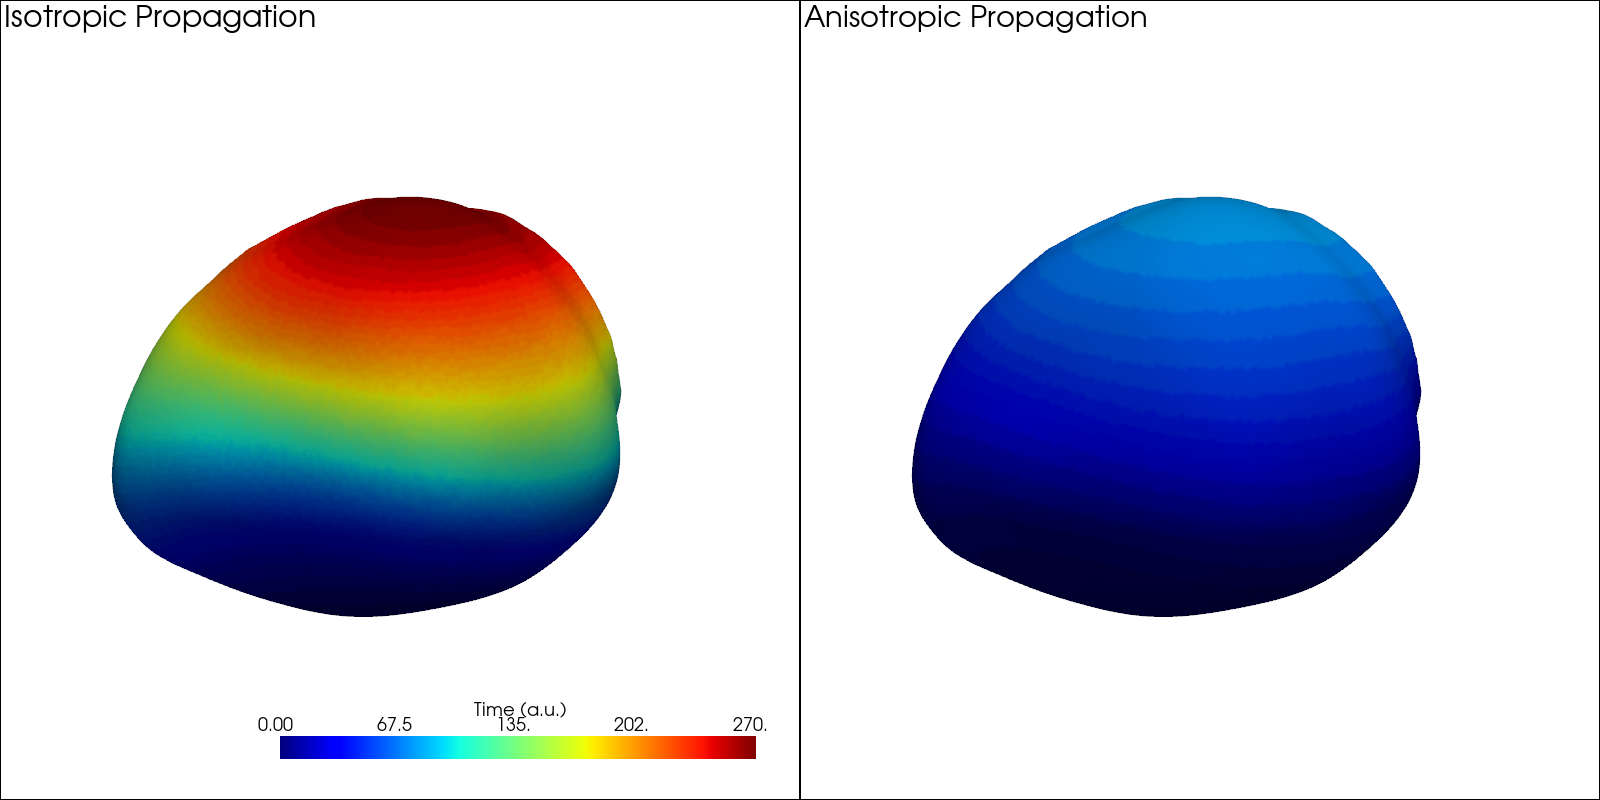

In [6]:
import pyvista as pv

# Set backend
pv.set_jupyter_backend('static')


# Upload the 2 .pvd files just saved (move them from the folder to the more general folder)
mesh_iso = pv.read("mappa_attivazione_isotropa.pvd")
mesh_ani = pv.read("mappa_attivazione_anisotropa.pvd")

# Plot with 2 subplots
plotter = pv.Plotter(shape=(1, 2), window_size=[1600, 800])

# Left panel: isotropic
plotter.subplot(0, 0)
plotter.add_text("Isotropic Propagation", font_size=14, color="black")
plotter.add_mesh(mesh_iso, scalars="ActivationTime", cmap="jet",
                 show_scalar_bar=True, scalar_bar_args={'title': 'Time (a.u.)'})
plotter.view_xz()
plotter.camera.azimuth += 120
plotter.camera.elevation += 20

# Right panel: anisotropic
plotter.subplot(0, 1)
plotter.add_text("Anisotropic Propagation", font_size=14, color="black")
plotter.add_mesh(mesh_ani, scalars="ActivationTime", cmap="jet",
                 show_scalar_bar=True, scalar_bar_args={'title': 'Time (a.u.)'})
plotter.view_xz()

# Link views
plotter.link_views()

plotter.screenshot("confronto_attivazione_ventricolo.png")

print("Generation image...")
plotter.show()

Videos of Isotropy and Anisotropy activation


In [ ]:
import pyvista as pv
import numpy as np
import os

# Data upload
file_risultato = "mappa_attivazione_anisotropa_0.vtu"

try:
    mesh = pv.read(file_risultato)
    print("Mesh successfully loaded for animation!")
except FileNotFoundError:
    print(f"ERROR: File {result_file} not found. Check the exact name of the .vtu file!")
    exit()

nome_variabile = "ActivationTime"

# Force PyVista to use data associated with physical mesh nodes (59,235),
# ignoring extra metadata (DoFs) saved by Firedrake (156,587).
if nome_variabile in mesh.point_data:
    t_act = mesh.point_data[nome_variabile].copy()
else:
    mesh.set_active_scalars(nome_variabile)
    t_act = mesh.active_scalars.copy()

# Find the maximum simulation time (ignoring -1.0 values for unactivated nodes)
max_time = np.max(t_act)
print(f"Tempo di attivazione massimo rilevato: {max_time:.2f}")

# Plotter setup for video
plotter = pv.Plotter(off_screen=True, window_size=[1280, 720])

nome_video = "animazione_onda_anisotropa.gif"
plotter.open_gif(nome_video, fps=22) # Lower FPS for a smoother view

# Initial array: set everything to -1.0 (which will correspond to dark blue/background)
mesh["Stato_Corrente"] = np.full_like(t_act, -1.0)

# Add the mesh: 'jet' colormap and set the range from 0.0 to the max time
plotter.add_mesh(mesh,
                 scalars="Stato_Corrente",
                 cmap="jet",
                 clim=[0.0, max_time], # The gradient covers the exact simulation time range
                 show_scalar_bar=True,
                 scalar_bar_args={'title': 'Tempo di Attivazione (a.u.)', 'color': 'black'},
                 smooth_shading=True)

plotter.set_background("white")

plotter.view_xz()
plotter.camera.roll += 270

# Animation loop
num_frames = 100
print(f"Generating {num_frames} frames...")

for t in np.linspace(0, max_time, num_frames):

    # If the node has already been activated (t_act <= t), assign its actual time (t_act).
    # If not activated yet, leave it at -1.0 (outside the colormap range, dark blue/invisible).
    mesh["Stato_Corrente"][:] = np.where((t_act >= 0) & (t_act <= t), t_act, -1.0)

    # Add a text overlay displaying current time
    plotter.add_text(f"Tempo: {t:.1f} a.u.", position='upper_right', color='black', name="time_label")

    # Save
    plotter.write_frame()

plotter.close()
print(f"Done, video saved as: {nome_video}")

Mesh successfully loaded for animation!
Tempo di attivazione massimo rilevato: 75.00
Generating 100 frames...


In [ ]:
import pyvista as pv
import numpy as np
import os

# Data upload
file_risultato = "mappa_attivazione_isotropa_0.vtu"

try:
    mesh = pv.read(file_risultato)
    print("Mesh successfully loaded for animation!")
except FileNotFoundError:
    print(f"ERROR: File {result_file} not found. Check the exact name of the .vtu file!")
    exit()

nome_variabile = "ActivationTime"

# Force PyVista to use data associated with physical mesh nodes (59,235),
# ignoring extra metadata (DoFs) saved by Firedrake (156,587).
if nome_variabile in mesh.point_data:
    t_act = mesh.point_data[nome_variabile].copy()
else:
    mesh.set_active_scalars(nome_variabile)
    t_act = mesh.active_scalars.copy()

# Find the maximum simulation time (ignoring -1.0 values for unactivated nodes)
max_time = np.max(t_act)
print(f"Tempo di attivazione massimo rilevato: {max_time:.2f}")

# Plotter setup for the video
plotter = pv.Plotter(off_screen=True, window_size=[1280, 720])

nome_video = "animazione_onda_isotropa.gif"
plotter.open_gif(nome_video, fps=12)

# Initial array: set everything to -1.0 (which will correspond to dark blue/background)
mesh["Stato_Corrente"] = np.full_like(t_act, -1.0)

# Add the mesh: 'jet' colormap and set the range from 0.0 to the max time
plotter.add_mesh(mesh,
                 scalars="Stato_Corrente",
                 cmap="jet",
                 clim=[0.0, max_time],
                 show_scalar_bar=True,
                 scalar_bar_args={'title': 'Tempo di Attivazione (a.u.)', 'color': 'black'},
                 smooth_shading=True)

plotter.set_background("white")

plotter.view_xz()
plotter.camera.roll += 270

# Animation loop
num_frames = 60
print(f"Generating {num_frames} frames...")

for t in np.linspace(0, max_time, num_frames):

    # If the node has already been activated (t_act <= t), assign its actual time (t_act).
    # If not activated yet, leave it at -1.0 (outside the colormap range, dark blue/invisible).
    mesh["Stato_Corrente"][:] = np.where((t_act >= 0) & (t_act <= t), t_act, -1.0)

    # Add a text overlay displaying current time
    plotter.add_text(f"Tempo: {t:.1f} a.u.", position='upper_right', color='black', name="time_label")

    # Save
    plotter.write_frame()

# Chiudi il file video
plotter.close()
print(f"Done, video saved as: {nome_video}")

Mesh successfully loaded for animation!
Tempo di attivazione massimo rilevato: 245.00
Generating 60 frames...
Done, video saved as: animazione_onda_isotropa.gif
